<a href="{{ colab_base_laboratorios }}/Laboratorio_02_pandas_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Santiago Andrés Angulo Toro 1001154362


# Lab 2: Estadística Descriptiva Básica 2

## Series de tiempo

El siguiente [dataset](https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Pandas_data_historical_dataEURUSD.csv) contiene información del precio del eur/usd  desde el 05/07/2022/ hasta el 12/05/2023 con periodicidad de una hora. El data frame contiene el precio de apertura, cierrre, valor más bajo cotizado, valor más alto cotizado, volumen, spread etc. Para este dataset, realizar lo siguiente:


1. Leer el dataset desde el github.
2. Definir como indice la columna time.
3. Obtenga información del data frame.

4. Determine si hay null, nan en el data frame.

5. Emplea la notacion Pascal Case y trabaja solo con la columa del precio de cierre del eur/usd.  

6. Ahora vamos a determinar cual es la mejor distribución estadística que se ajusta a la diferencia del precio de cierre cada hora, para ello realizamos lo siguiente:
- Determine la diferencia de precio entre horas, agregue una nueva columna llamada DiffPrice, en este punto tu dataframe debe tener solo dos columnas Close, DiffPrice y el indice debe ser el tiempo.
- Para la nueva columna construya un histograma de los datos.
- Determine la mejor distribucion estadística que se ajusta al histograma anterior, para ello puede emplear lo siguente:


https://pypi.org/project/fitter/

```python


from fitter import Fitter, get_common_distributions, get_distributions

f = Fitter(data,
           distributions=['gamma',
                          'lognorm',
                          "beta",
                          "burr",
                          "norm"])
f.fit()
f.summary()
#Indentificamos la mejor distribucion con el error cuadratico medio
f.get_best(method = 'sumsquare_error')
#Indentificamos parametros de la distrubicion beta
f.fitted_param["beta"]

```

Con el metodo get_distributions(), podemos ver todas las distribuciones estadisticas de la libreria. Ajusta a la mejor.  Puede consultar [esta](https://medium.com/the-researchers-guide/finding-the-best-distribution-that-fits-your-data-using-pythons-fitter-library-319a5a0972e9)  página si desea ver un ejemplo.


7. Para el data frame, seleccionemos solo los datos del 2023.

8. El comando groupby permite agrupar los datos con la periodicidad deseada: 1 dias, 2 dias, 1 mes etc. Determina el promedio con una periodicidad de 15 dias, con periodidicidad de 1 semana, y una periodicidad de 1 mes

```python
  df.groupby(pd.Grouper(key='time', freq='15D')).mean()
```

9. Para los datos asociados a los meses de 2023, construya un histograma para cada mes.  Para ello puedo emplear el metodo groupby. Notetese que si no  realiza una operación después de aplicar el metodo grouby, podrias iterar sobre dicho objeto, por ejemplo:

```python
q=df.groupby(pd.Grouper(key='time', freq='15D'))

for name, group in q:
  print(name, group)
```


## Análisis de datos con pandas.

Para el siguiente [dataset](https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+%28Diagnostic%29) realizar lo siguiente:


1. Leer los datos desde una página web.

2. Renombrar las columnas en formato PascalCase.

3. Utilizar los métodos `head()`, `tail()`, `describe()` e `info()` para obtener información sobre el `DataFrame`.

4. Contabilizar la cantidad de valores nulos (`null` o `NaN`) en el `DataFrame`.
   Si se encuentran valores nulos, ¿qué estrategia propondrías para reemplazarlos?

5. Identificar los valores únicos en la columna `target` que representan las etiquetas B y M (Benigno y Maligno, respectivamente).
   Utiliza el método `unique()` para mostrar estos valores.

6. Realizar un conteo de los casos etiquetados como B y M utilizando la librería `seaborn` y el método `countplot()`:

```python
import seaborn as sns
sns.countplot?
```

7. Agregar una nueva columna llamada `DiagnosisNumeric` donde se asigna el valor 0 a la etiqueta B (Benigno) y el valor 1 a la etiqueta M (Maligno).


8. Normalizar cada columna respecto a su media y desviación estándar utilizando la fórmula:  
   `(x - mean(x)) / std(x)`

9. Agrupar características similares y calcular su promedio.
   Para las siguientes características:

```python
['RadiusMean', 'TextureMean', 'PerimeterMean', 'AreaMean', 'SmoothnessMean', 'CompactnessMean', 'ConcavityMean', 'ConcavePointsMean', "SymmetryMean", "FractalDimensionMean"]
```

Usa expresiones regulares para identificar patrones comunes, como `radius1`, `radius2`,`radius3`, etc., y calcular los promedios. Por ejemplo:

```python
re.match(r'^[a-zA-Z_]+', "holamundo12341").group(0)
```

También puedes utilizar el método `startswith()` para buscar estos patrones en los nombres de las columnas.


10. Crear un gráfico donde se muestre el histograma de la columna `RadiusMean` separado por las etiquetas B y M, utilizando colores diferentes (naranja y azul, respectivamente) para cada diagnóstico.

11. Generar gráficos de violín para múltiples características.
   Para las columnas:

   - `RadiusMean`
   - `TextureMean`
   - `PerimeterMean`
   - `AreaMean`
   - `SmoothnessMean`
   - `CompactnessMean`
   - `ConcavityMean`
   - `ConcavePointsMean`
   - `Symmetry3`
   - `FractalDimension3`

   Realiza un gráfico múltiple tipo violín, como en el siguiente ejemplo:

```python
data = pd.melt(df.iloc[:, 0:10], id_vars="Diagnosis", var_name="features", value_name="value")
sns.violinplot(x="features", y="value", hue="Diagnosis", data=data, split=True, inner="quart")
plt.xticks(rotation=45)
```


12.  Determinar y eliminar los valores atípicos (`outliers`) en la columna `RadiusMean`.

Para identificarlos, construye un gráfico tipo `boxplot`:

```python
df.boxplot(column="RadiusMean", by='Diagnosis', sym='k.', figsize=(18,6))
```

Usa el rango intercuartílico (IQR) para definir los outliers. Los valores fuera del rango [Q1 - 1.5 * IQR, Q3 + 1.5 * IQR] se consideran outliers. Ejemplo de cómo eliminar estos valores:

```python
Q1 = df['edad'].quantile(0.25)
Q3 = df['edad'].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df['edad'] < (Q1 - 1.5 * IQR)) | (df['edad'] > (Q3 + 1.5 * IQR)))]
```

Otra alternativa es utilizar el puntaje Z para detectar `outliers`:

```python
df = df[(np.abs(stats.zscore(df['edad'])) < 3)]
```



13. Encontrar la matrix de correlación, emplear el metodo corr(), dentro de seaborn buscar el metodo heatmap() para realizar un grafico de la matrix de correlación.

14. ¿Que otro tipo de gráficos pueden ser realizados para entender mejor los datos?



In [3]:
!pip install fitter

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# pip install fitter (si no está instalada en el entorno)
from fitter import Fitter

# 1. Leer el dataset desde el github
url_eur_usd = "https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Pandas_data_historical_dataEURUSD.csv"
datos_divisa = pd.read_csv(url_eur_usd)

# 2. Definir como indice la columna time
# Primero convierto la columna a tipo datetime para poder usar bien las fechas
datos_divisa['time'] = pd.to_datetime(datos_divisa['time'])
datos_divisa.set_index('time', inplace=True)

# 3. Obtenga información del data frame
print("Información del DataFrame:")
datos_divisa.info()

# 4. Determine si hay null, nan en el data frame
nulos = datos_divisa.isnull().sum()
print("\nCantidad de nulos por columna:\n", nulos)

Información del DataFrame:
<class 'pandas.DataFrame'>
DatetimeIndex: 5000 entries, 2022-07-25 13:00:00 to 2023-05-12 23:00:00
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          5000 non-null   int64  
 1   open                5000 non-null   float64
 2   high                5000 non-null   float64
 3   low                 5000 non-null   float64
 4   close               5000 non-null   float64
 5   tick_volume         5000 non-null   int64  
 6   spread              5000 non-null   int64  
 7   real_volume         5000 non-null   int64  
 8   MeanCloseOpen       5000 non-null   float64
 9   Diff_Close          5000 non-null   float64
 10  Diff_Open           5000 non-null   float64
 11  Diff_MeanCloseOpen  5000 non-null   float64
dtypes: float64(8), int64(4)
memory usage: 507.8 KB

Cantidad de nulos por columna:
 Unnamed: 0            0
open                  0
high                  

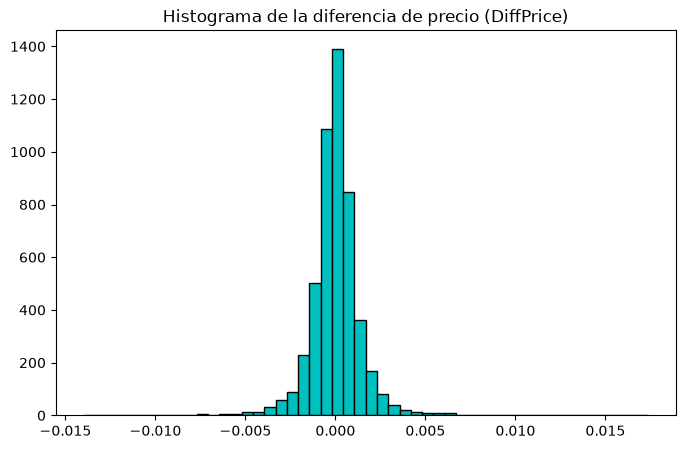


Resumen de distribuciones:
         sumsquare_error           aic           bic     kl_div  ks_statistic  \
lognorm    106500.661168 -51509.765589 -51490.214609   0.101912      0.091597   
beta       106677.525909 -51503.229672 -51477.161699   0.102011      0.090756   
norm       106744.023571 -51505.717419 -51492.683433   0.102054      0.090533   
burr       721804.561088 -37765.252892 -37739.184919   7.480557      0.386409   
gamma      923360.482403 -17723.242274 -17703.691294  14.865645      0.591356   

            ks_pvalue  
lognorm  5.996555e-37  
beta     2.794092e-36  
norm     4.194767e-36  
burr     0.000000e+00  
gamma    0.000000e+00  

La mejor distribución según el error cuadrático medio es: {'lognorm': {'s': np.float64(0.009509964461157715), 'loc': np.float64(-0.1471693008245066), 'scale': np.float64(0.14717494036949658)}}


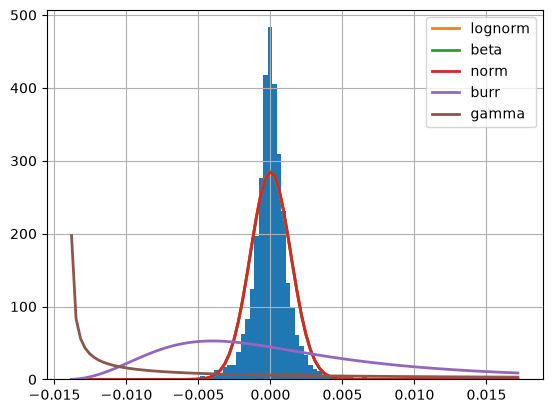

In [6]:
# 5. Emplea la notacion Pascal Case y trabaja solo con la columa del precio de cierre
# Pongo la primera letra en mayúscula para PascalCase
datos_divisa.columns = [columna.title().replace(' ', '') for columna in datos_divisa.columns]

# Me quedo únicamente con la columna 'Close'
df_cierre = datos_divisa[['Close']].copy()

# 6. Distribución estadística a la diferencia del precio
# Agregar columna DiffPrice
df_cierre['DiffPrice'] = df_cierre['Close'].diff()
# Borramos el primer dato que queda en NaN por la diferencia
df_cierre = df_cierre.dropna()

# Histograma de los datos
plt.figure(figsize=(8,5))
plt.hist(df_cierre['DiffPrice'], bins=50, color='c', edgecolor='black')
plt.title('Histograma de la diferencia de precio (DiffPrice)')
plt.show()

# Determinar mejor distribución con fitter
# Tomamos los valores de DiffPrice
datos_fitter = df_cierre['DiffPrice'].values

f = Fitter(datos_fitter,
           distributions=['gamma', 'lognorm', 'beta', 'burr', 'norm'])
f.fit()
print("\nResumen de distribuciones:")
print(f.summary())

# Identificamos la mejor
mejor_distribucion = f.get_best(method='sumsquare_error')
print("\nLa mejor distribución según el error cuadrático medio es:", mejor_distribucion)

# 7. Seleccionar solo los datos del 2023
datos_2023 = df_cierre.loc['2023']

# 8. Promedios con diferentes periodicidades usando groupby
promedio_15_dias = datos_2023.groupby(pd.Grouper(freq='15D')).mean() # Este no cambia[cite: 17]
promedio_1_semana = datos_2023.groupby(pd.Grouper(freq='1W')).mean()
promedio_1_mes = datos_2023.groupby(pd.Grouper(freq='1ME')).mean() # <-- Corrección aquí

# 9. Histograma para cada mes del 2023
meses = datos_2023.groupby(pd.Grouper(freq='1ME')) # <-- Corrección aquí

Primeras filas:
         Id Diagnosis  RadiusMean  TextureMean  PerimeterMean  AreaMean  \
0    842302         M       17.99        10.38         122.80    1001.0   
1    842517         M       20.57        17.77         132.90    1326.0   
2  84300903         M       19.69        21.25         130.00    1203.0   
3  84348301         M       11.42        20.38          77.58     386.1   
4  84358402         M       20.29        14.34         135.10    1297.0   

   SmoothnessMean  CompactnessMean  ConcavityMean  ConcavePointsMean  ...  \
0         0.11840          0.27760         0.3001            0.14710  ...   
1         0.08474          0.07864         0.0869            0.07017  ...   
2         0.10960          0.15990         0.1974            0.12790  ...   
3         0.14250          0.28390         0.2414            0.10520  ...   
4         0.10030          0.13280         0.1980            0.10430  ...   

   RadiusWorst  TextureWorst  PerimeterWorst  AreaWorst  SmoothnessWor

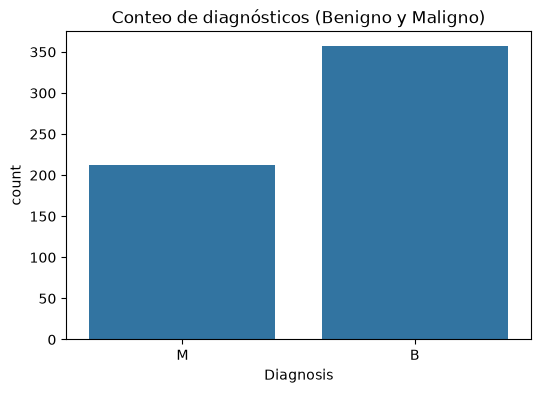


Promedio agrupado por características base:
{'Radius': np.float64(-2.3934509259640164e-16), 'Texture': np.float64(-1.665009339801055e-17), 'Perimeter': np.float64(-1.9147607407712131e-16), 'Area': np.float64(-1.1030686876181988e-16), 'Smoothness': np.float64(-4.110491807633854e-16), 'Compactness': np.float64(1.2487570048507903e-17), 'Concavity': np.float64(9.365677536380934e-17), 'ConcavePoints': np.float64(5.827532689303693e-17), 'Symmetry': np.float64(1.8106976570336472e-16), 'FractalDimension': np.float64(-3.2259555958645434e-17)}


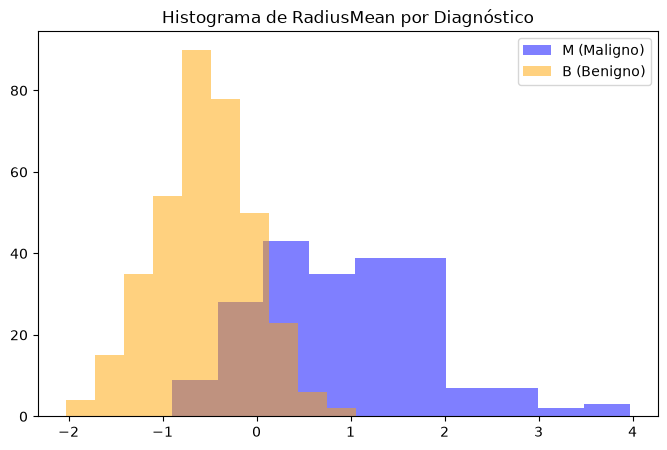

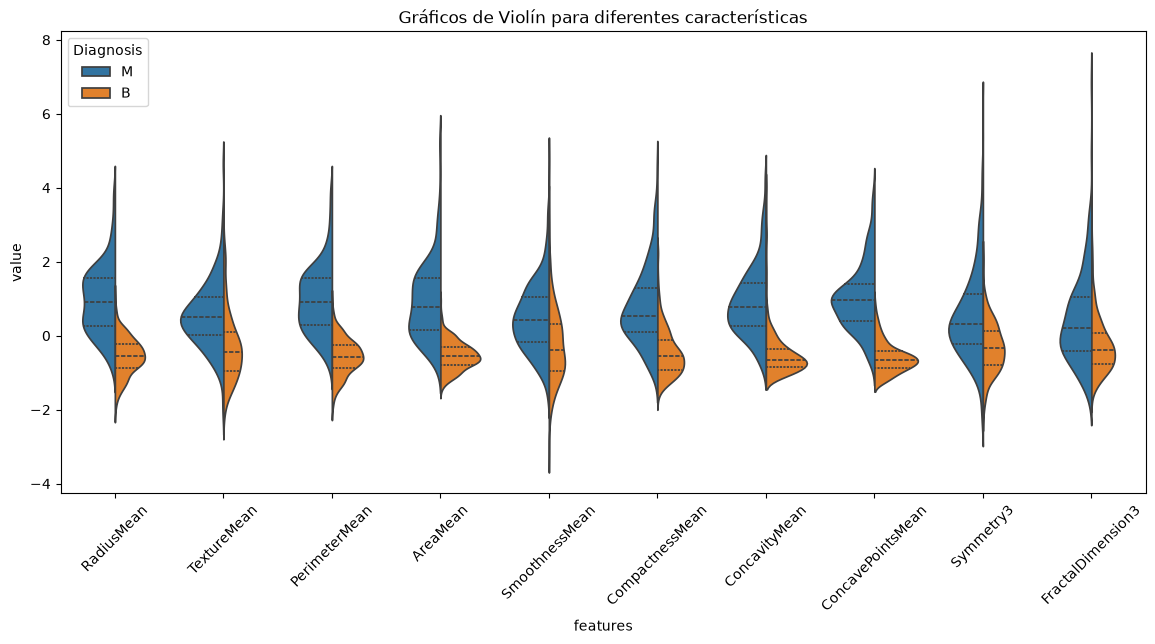

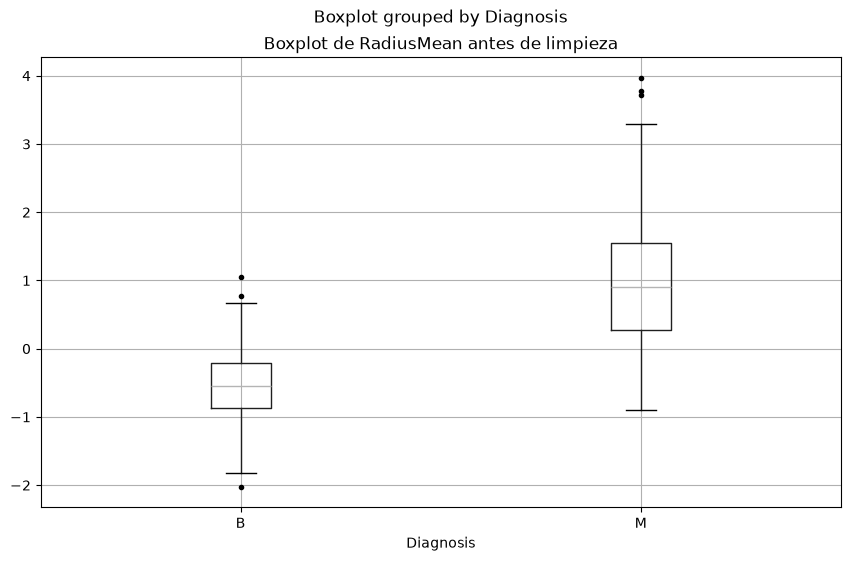


Tamaño original: 569. Tamaño tras limpiar RadiusMean: 555


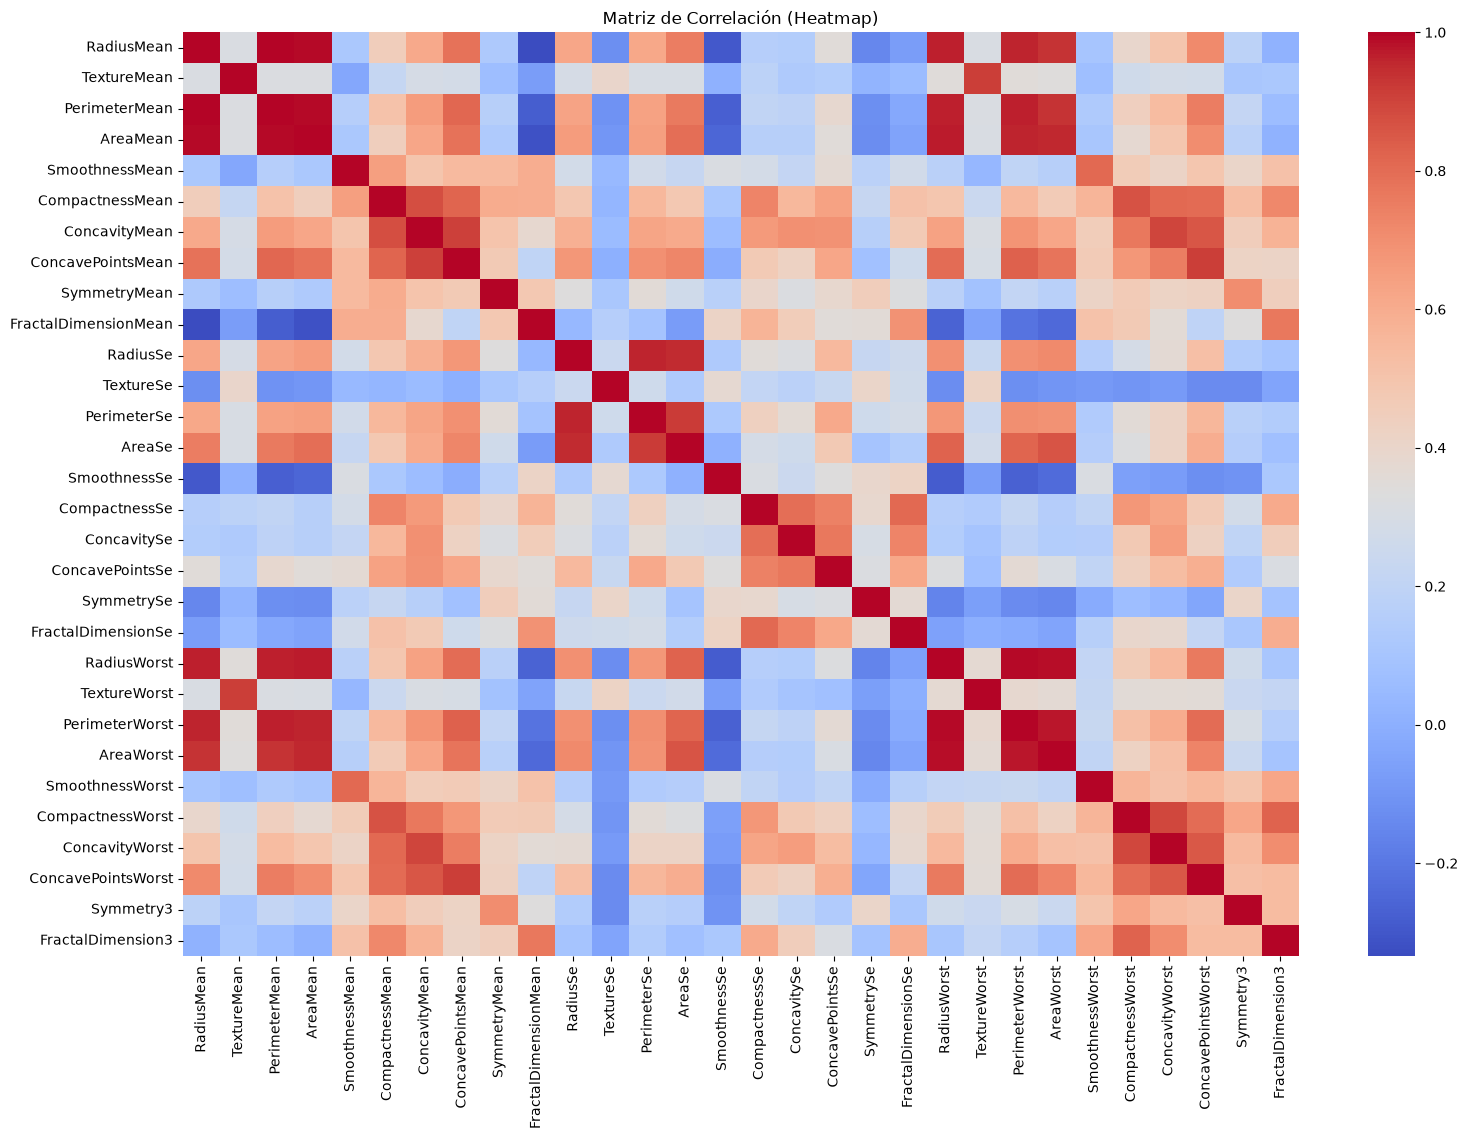

In [7]:
import seaborn as sns
import re
from scipy import stats

# 1. Leer los datos desde la página web (usando la ruta raw del archivo .data)
url_cancer = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"

# 2. Renombrar las columnas en formato PascalCase
# Se definen los nombres siguiendo la estructura del dataset de Wisconsin
nombres_columnas = ['Id', 'Diagnosis', 'RadiusMean', 'TextureMean', 'PerimeterMean', 'AreaMean',
                    'SmoothnessMean', 'CompactnessMean', 'ConcavityMean', 'ConcavePointsMean',
                    'SymmetryMean', 'FractalDimensionMean', 'RadiusSe', 'TextureSe', 'PerimeterSe',
                    'AreaSe', 'SmoothnessSe', 'CompactnessSe', 'ConcavitySe', 'ConcavePointsSe',
                    'SymmetrySe', 'FractalDimensionSe', 'RadiusWorst', 'TextureWorst',
                    'PerimeterWorst', 'AreaWorst', 'SmoothnessWorst', 'CompactnessWorst',
                    'ConcavityWorst', 'ConcavePointsWorst', 'Symmetry3', 'FractalDimension3']

datos_cancer = pd.read_csv(url_cancer, names=nombres_columnas)

# 3. Métodos de información
print("Primeras filas:")
print(datos_cancer.head())
print("\nÚltimas filas:")
print(datos_cancer.tail())
print("\nEstadísticas descriptivas:")
print(datos_cancer.describe())
print("\nInformación del DataFrame:")
datos_cancer.info()

# 4. Contabilizar nulos
total_nulos = datos_cancer.isnull().sum().sum()
print(f"\nCantidad total de nulos en el dataset: {total_nulos}")
# Respuesta a la estrategia: Pues si encontrara valores nulos, propondría reemplazarlos usando la media
# o mediana de la columna correspondiente dependiendo de si hay muchos valores atípicos o que no van.

# 5. Valores únicos en la columna target (Diagnosis)
valores_unicos = datos_cancer['Diagnosis'].unique()
print("\nEtiquetas únicas de diagnóstico:", valores_unicos)

# 6. Conteo de B y M con seaborn
plt.figure(figsize=(6,4))
sns.countplot(x='Diagnosis', data=datos_cancer)
plt.title('Conteo de diagnósticos (Benigno y Maligno)')
plt.show()

# 7. Agregar columna DiagnosisNumeric (B=0, M=1)
datos_cancer['DiagnosisNumeric'] = datos_cancer['Diagnosis'].map({'B': 0, 'M': 1})

# 8. Normalizar cada columna (menos las de ID y categorías)
columnas_numericas = datos_cancer.select_dtypes(include=[np.number]).columns
# Quitamos el Id y el target numérico para no normalizarlos
columnas_numericas = columnas_numericas.drop(['Id', 'DiagnosisNumeric'])

for col in columnas_numericas:
    datos_cancer[col] = (datos_cancer[col] - datos_cancer[col].mean()) / datos_cancer[col].std()

# 9. Agrupar características similares y sacar promedio
# Usaré expresiones regulares para buscar los sufijos o comienzos comunes
caracteristicas = ['Radius', 'Texture', 'Perimeter', 'Area', 'Smoothness',
                   'Compactness', 'Concavity', 'ConcavePoints', 'Symmetry', 'FractalDimension']

promedios_grupos = {}
for caracteristica in caracteristicas:
    # Buscar todas las columnas que empiecen con el nombre de la característica
    cols_similares = [col for col in datos_cancer.columns if re.match(rf'^{caracteristica}', col)]
    # Promedio del grupo (promedio de los promedios de esas columnas)
    promedios_grupos[caracteristica] = datos_cancer[cols_similares].mean().mean()

print("\nPromedio agrupado por características base:")
print(promedios_grupos)

# 10. Histograma RadiusMean separado por colores
plt.figure(figsize=(8,5))
plt.hist(datos_cancer[datos_cancer['Diagnosis'] == 'M']['RadiusMean'], color='blue', alpha=0.5, label='M (Maligno)')
plt.hist(datos_cancer[datos_cancer['Diagnosis'] == 'B']['RadiusMean'], color='orange', alpha=0.5, label='B (Benigno)')
plt.title('Histograma de RadiusMean por Diagnóstico')
plt.legend()
plt.show()

# 11. Gráfico múltiple tipo violín
columnas_violin = ['RadiusMean', 'TextureMean', 'PerimeterMean', 'AreaMean',
                   'SmoothnessMean', 'CompactnessMean', 'ConcavityMean',
                   'ConcavePointsMean', 'Symmetry3', 'FractalDimension3']

# Agregamos la columna 'Diagnosis' a la lista para hacer el melt
data_melt = pd.melt(datos_cancer, id_vars="Diagnosis", value_vars=columnas_violin,
                    var_name="features", value_name="value")

plt.figure(figsize=(14, 6))
sns.violinplot(x="features", y="value", hue="Diagnosis", data=data_melt, split=True, inner="quart")
plt.xticks(rotation=45)
plt.title('Gráficos de Violín para diferentes características')
plt.show()

# 12. Determinar y eliminar outliers usando boxplot e IQR
datos_cancer.boxplot(column="RadiusMean", by='Diagnosis', sym='k.', figsize=(10,6))
plt.title('Boxplot de RadiusMean antes de limpieza')
plt.show()

Q1 = datos_cancer['RadiusMean'].quantile(0.25)
Q3 = datos_cancer['RadiusMean'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtramos quitando los outliers
datos_sin_atipicos = datos_cancer[~((datos_cancer['RadiusMean'] < limite_inferior) |
                                    (datos_cancer['RadiusMean'] > limite_superior))]

print(f"\nTamaño original: {len(datos_cancer)}. Tamaño tras limpiar RadiusMean: {len(datos_sin_atipicos)}")

# 13. Matriz de correlación y heatmap
# Se calcula la correlación solo con las variables numéricas
matriz_correlacion = datos_sin_atipicos[columnas_numericas].corr()

plt.figure(figsize=(18, 12))
sns.heatmap(matriz_correlacion, cmap="coolwarm", annot=False)
plt.title('Matriz de Correlación (Heatmap)')
plt.show()

# 14. ¿Qué otro tipo de gráficos pueden ser realizados?

# Podríamos realizar un 'Pairplot' (sns.pairplot) para ver diagramas de dispersión multivariados
# que nos ayudarían a encontrar relaciones lineales entre pares de variables específicas, o un
# 'Scatter plot' (gráfico de dispersión) en 2D y 3D usando PCA (Análisis de Componentes Principales)
# para visualizar mejor la frontera de separación entre tumores malignos y benignos.